In [1]:
!pip install --quiet scikit-learn

In [2]:
%cd ..

/Users/danorel/Workspace/Education/University/NYU/Research/xeda


In [3]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
import random
import chromadb
import copy
import json
import typing as t
import pandas as pd
import numpy as np
import uuid
import pathlib
import s3fs

from chromadb.utils import embedding_functions
from dagster import EnvVar
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

from pipeline.resources import S3FSResource
from pipeline.solid.pipeline_annotator import annotate_pipeline
from pipeline.solid.utils.model_manager import ModelManager
from pipeline.solid.utils.pipelines.pipeline_precalculated_sets import PipelineWithPrecalculatedSets
from typings.pipeline import OperatorRequestData


from constants import (
    AWS_ACCESS_KEY_ID,
    AWS_SECRET_ACCESS_KEY,
    AWS_S3_ENDPOINT_URL,
    AWS_S3_REGION_NAME,
    AWS_S3_BUCKET_NAME,
    AWS_S3_USE_SSL,
    GROUPS_CSV_PATH,
    OPENAI_API_KEY,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_HOST,
    VECTOR_STORE_PORT,
    UNIVERSAL_POLICY_NAME
)
from typings.pipeline import Pipeline
from pipeline.solid.pipeline_sampler import next_pipeline_iter
from utils.s3 import pull_keras_model

2024-04-12 16:27:08.889314: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
pretrained_embeddings = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-ada-002"
)

vector_store = chromadb.HttpClient(
    host=VECTOR_STORE_HOST, 
    port=VECTOR_STORE_PORT
)

In [6]:
vector_collection = vector_store.get_collection(VECTOR_STORE_COLLECTION)

In [7]:
fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    endpoint_url=AWS_S3_ENDPOINT_URL,
    use_ssl=AWS_S3_USE_SSL,
    client_kwargs={"region_name": AWS_S3_REGION_NAME},
)

In [8]:
database_pipeline_cache = {}
database_pipeline_cache["galaxies"] = PipelineWithPrecalculatedSets(
    "sdss",
    ["galaxies"],
    discrete_categories_count=10,
    min_set_size=10,
    exploration_columns=[
        "galaxies.u",
        "galaxies.g",
        "galaxies.r",
        "galaxies.i",
        "galaxies.z",
        "galaxies.petroRad_r",
        "galaxies.redshift",
    ],
    id_column="galaxies.objID",
)

In [9]:
model_manager = ModelManager(database_pipeline_cache["galaxies"], models = {
    "set": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="set_actor",
    ),
    "operation": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="operation_actor",
    ),
    "set_op_counters": None,
})

In [10]:
groups_df = pd.read_csv(GROUPS_CSV_PATH)

In [11]:
annotated_pipelines = []
for annotated_file in fs.glob('annotated_pipelines/*.json'):
    with annotated_file.open('r') as f:
        annotated_pipelines.append(json.load(f))

In [12]:
for annotated_pipeline in annotated_pipelines:
    (
        pipeline_ids,
        pipeline_documents,
        pipeline_sentences
    ) = pipeline_to_embedding(annotated_pipeline)
    vector_collection.add(
        ids=pipeline_ids,
        documents=pipeline_documents,
        embeddings=pretrained_embeddings(pipeline_sentences),
    )

In [13]:
pipeline_collection = vector_collection.get()

In [14]:
def node_to_encoding(node, only_annotation = True):
    if only_annotation:
        annotation = node.get('annotation')
    else:
        annotation = node
    if annotation == None:
        return ''
    node_encoding = []
    for k, v in annotation.items():
        if isinstance(v, dict):
            for key in v:
                node_encoding.append(f"{k}_{key} = {v[key]}")
        else:
            node_encoding.append(f"{k} = {v}")
    return ', '.join(node_encoding)


def pipeline_to_splits(pipeline: Pipeline) -> t.List[Pipeline]:
    splits = []
    pipeline_encoding = []
    for node in reversed(pipeline):
        node_encoding = node_to_encoding(node)
        pipeline_encoding.append(node_encoding)
        splits.append(copy.deepcopy(pipeline_encoding))
    return splits


def pipeline_to_embedding(pipeline: Pipeline):
    pipeline_splits = pipeline_to_splits(pipeline)
    pipeline_payload = (
        [str(uuid.uuid4()) for _ in range(len(pipeline_splits))],
        [json.dumps(copy.deepcopy(pipeline)) for _ in range(len(pipeline_splits))],
        [';'.join(pipeline_split) for pipeline_split in pipeline_splits]
    )
    return pipeline_payload

In [15]:
def select_attributes(pipeline: Pipeline):
    return f"{[node['operator'] for node in pipeline]}"


def explore_pipeline(partial_pipeline: Pipeline, database_pipeline_cache, k: int):
    # This is a stub to simulate pipeline exploration.
    # In a real scenario, this would involve applying transformations or decisions based on an RL model.

    partial_latest_node = partial_pipeline[-1]
    partial_latest_request_data = partial_latest_node.get("requestData")
    
    terminal_request_data = OperatorRequestData(**partial_latest_request_data)
    terminal_pipeline = partial_pipeline.copy()
    
    for i in range(len(partial_pipeline), len(partial_pipeline) + k):
        try:
            terminal_node, terminal_request_data = next_pipeline_iter(
                database_pipeline_cache,
                model_manager,
                terminal_request_data
            )
            terminal_pipeline.append(terminal_node)
        except ValueError:
            print(f"Unexpectedly exited from pipeline generation on step {i}. Saving pipeline as it is...")
            break
    
    return annotate_pipeline(groups_df, terminal_pipeline)


def make_experiment(pipeline_index: int, type_of_similarity: str, k: int, verbose: bool = False):
    ids  = pipeline_collection['ids']
    docs = pipeline_collection['documents']

    partial_pipeline_id   = ids[pipeline_index]
    partial_pipeline = json.loads(docs[pipeline_index])
    
    rest_pipeline_ids = ids[:pipeline_index] + ids[pipeline_index+1:]
    rest_pipelines = [json.loads(doc) for doc in docs[:pipeline_index] + docs[pipeline_index+1:]]
    
    (
        partial_pipeline_ids,
        partial_pipeline_documents,
        partial_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    
    partial_annotation_embedding = pretrained_embeddings(partial_pipeline_sentences)
    partial_response = vector_collection.query(
        query_embeddings=partial_annotation_embedding,
        n_results=len(rest_pipeline_ids),
        include=["distances", "documents"]
    )
    
    terminal_pipeline = explore_pipeline(partial_pipeline, database_pipeline_cache, k=k)
    (
        terminal_pipeline_ids,
        terminal_pipeline_documents,
        terminal_pipeline_sentences
    ) = pipeline_to_embedding(terminal_pipeline)
    terminal_annotation_embedding = pretrained_embeddings(terminal_pipeline_sentences)
    
    if verbose:
        print(f"Terminal pipeline: {select_attributes(terminal_pipeline)}\n")

    partial_explanation_pipelines = partial_response['documents'][0]

    min_explanation_pipeline, max_explanation_pipeline = (
        json.loads(partial_explanation_pipelines[0]),
        json.loads(partial_explanation_pipelines[-1])
    )

    if verbose:
        print(f"Min pipeline: {min_explanation_distance}%, {select_attributes(min_explanation_pipeline)}")
        print(f"Max pipeline: {max_explanation_distance}%, {select_attributes(max_explanation_pipeline)}\n")

    (
        min_pipeline_ids,
        min_pipeline_documents,
        min_pipeline_sentences
    ) = pipeline_to_embedding(min_explanation_pipeline)
    min_annotation_embedding = pretrained_embeddings(min_pipeline_sentences)

    (
        max_pipeline_ids,
        max_pipeline_documents,
        max_pipeline_sentences
    ) = pipeline_to_embedding(max_explanation_pipeline)
    max_annotation_embedding = pretrained_embeddings(max_pipeline_sentences)

    terminal_annotation_embedding = np.array(terminal_annotation_embedding).mean(axis=0)
    min_annotation_embedding = np.array(min_annotation_embedding).mean(axis=0)
    max_annotation_embedding = np.array(max_annotation_embedding).mean(axis=0)
    
    if type_of_similarity == 'cosine':
        min_to_terminal_similarity = np.dot(terminal_annotation_embedding, min_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(min_annotation_embedding))
        max_to_terminal_similarity = np.dot(terminal_annotation_embedding, max_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(max_annotation_embedding))
    elif type_of_similarity == 'euclidian':
        min_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - min_annotation_embedding)
        max_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - max_annotation_embedding)
    elif type_of_similarity == 'manhattan':
        min_to_terminal_similarity = np.abs(terminal_annotation_embedding - min_annotation_embedding).sum()
        max_to_terminal_similarity = np.abs(terminal_annotation_embedding - max_annotation_embedding).sum()
    else:
        raise NotImplementedError("Unknown type of similarity")
    
    return {
        "partial_pipeline_id": partial_pipeline_id,
        "min_to_terminal_similarity": min_to_terminal_similarity,
        "max_to_terminal_similarity": max_to_terminal_similarity,
    }

def run_experiments(n: int = 1000, types_of_similarity: list = ['cosine'], exploration_steps: tuple = (3, 6)):
    measurements = pd.DataFrame()
    used_pipeline_ids = set()

    for experiment in tqdm(range(n)):

        print(f"Starting '{experiment + 1}' experiment")

        for k in range(*exploration_steps):

            print(f"Starting a measurement with '{k}' exploration steps")

            for type_of_similarity in types_of_similarity:

                print(f"Starting a measurement with '{type_of_similarity}' type of similarity")
    
                trial = 0
                target_pipeline_index, target_pipeline_id = None, None
                while (target_pipeline_id not in used_pipeline_ids):
                    trial += 1
                    print(f"Making {trial} trial to sample partial pipeline within not seen pipelines")
                    (
                        target_pipeline_index,
                        target_pipeline_id
                    ) = random.sample(list(enumerate(pipeline_collection['ids'])), k=1)[0]
                    if target_pipeline_id is not None:
                        used_pipeline_ids.add(target_pipeline_id)
                
                measurements = pd.concat([
                    measurements,
                    pd.DataFrame([{
                        "experiment": experiment + 1,
                        "k": k,
                        "type_of_similarity": type_of_similarity,
                        **make_experiment(
                            target_pipeline_index, 
                            type_of_similarity,
                            k, 
                            verbose=False
                        )
                    }])
                ])
        
                print(f"Recored a measurement for {experiment + 1}-th sample {target_pipeline_id}")

    return measurements

In [28]:
experiments_df = run_experiments(
    n=10,
    types_of_similarity=['manhattan', 'cosine', 'euclidian'],
    exploration_steps=(3, 6),
)

  0%|                                                                                                                   | 0/10 [00:00<?, ?it/s]

Starting '1' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'manhattan' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 27ms/step
[0.01736743 0.03818124 0.09779628 0.12376026 0.09744034 0.08726635
 0.06170846 0.20765978 0.15570586 0.11311401]
[0.037607153575703794, 0.08267702970170761, 0.21176648995598016, 0.26798845388589404, 0.21099573962646687, 0.18896513325424752, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 26ms/step
[0.04715815 0.06499706 0.03434923 0.09386517 0.02274274 0.0549722
 0.04035615 0.03382141 0.0639854  0.03860804 0.11706013 0.10845085
 0.08988986 0.06781116 0.06885638 0.05307606]
[0.07189754304161906, 0.09909483076835758, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05886200831501785, 0.1784704314052973, 0.16534468219706833, 0.13704650010002659, 0.10338522072123418, 0.10497876808152114, 0.0809200153698581]
by_neighbors-&-galaxies.r
1/1 [=

  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/pipeline_sampler/operators/by_neighbors.py", line 34, in by_neighbors
    prediction_result = model_manager.get_prediction(
  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/utils/model_manager.py", line 50, in get_prediction
    np.array(new_set_states).reshape(
 10%|██████████▌                                                                                               | 1/10 [06:08<55:15, 368.43s/it]

Recored a measurement for 1-th sample 72497535-e1a7-482d-a7e0-c8c75d558471
Starting '2' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'manhattan' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 24ms/step
[0.09609688 0.06455101 0.13124218 0.05146417 0.13026552 0.12476708
 0.0735473  0.05999576 0.16990823 0.09816187]
[0.13129246175079917, 0.08819288182063056, 0.1793097647772237, 0.07031297637197409, 0.17797541156935592, 0.17046315560224695, 0.10048408136368694, 0.08196926674408259, 0.0, 0.0]
1/1 [==============================] - 0s 26ms/step
[0.04588493 0.06301699 0.04206924 0.08733284 0.02464117 0.05986587
 0.03964666 0.03383174 0.0653307  0.03707371 0.1349356  0.10303
 0.09144314 0.06327618 0.06131774 0.04730349]
[0.07357454952910711, 0.10104507493795588, 0.0, 0.0, 0.0, 0.0, 0.06357174059326223, 0.0, 0.0, 0.0594461214380937, 0.21636352349230664, 0.165204245384319

  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/pipeline_sampler/operators/by_neighbors.py", line 34, in by_neighbors
    prediction_result = model_manager.get_prediction(
  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/utils/model_manager.py", line 50, in get_prediction
    np.array(new_set_states).reshape(
 20%|█████████████████████▏                                                                                    | 2/10 [12:36<50:41, 380.19s/it]

...

Recored a measurement for 9-th sample 8ce230c1-10d3-406f-8ad3-841464a4b620
Starting a measurement with 'euclidian' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 26ms/step
[0.07442149 0.10224232 0.21752066 0.04206375 0.10252151 0.18620648
 0.0329523  0.04708354 0.15736587 0.03762209]
[0.1026537046721369, 0.14102851546016412, 0.3000383420583917, 0.05802086745596578, 0.14141362048386924, 0.25684494986947215, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 27ms/step
[0.05787473 0.06407996 0.05691191 0.05002646 0.05119806 0.05575716
 0.056022   0.06119064 0.06799247 0.06240537 0.07646216 0.07470311
 0.08291611 0.07069235 0.06012689 0.05164063]
[0.09631319713656603, 0.10663974260098497, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.10385294677193982, 0.12724579240289638, 0.12431843029559127, 0.137986237977134, 0.11764386086227827, 0.1000611754291247, 0.08593861652348453]
by_neighbors-&-galaxies.redshift
1

 90%|█████████████████████████████████████████████████████████████████████████████████████████████▌          | 9/10 [1:02:34<07:28, 448.42s/it]

Recored a measurement for 9-th sample 89024319-8e7d-40b9-a95d-b298076fcb06
Starting '10' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'manhattan' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 22ms/step
[0.03948305 0.04744794 0.16200526 0.11963843 0.10898467 0.07597515
 0.06898819 0.06289698 0.22844909 0.08613122]
[0.06342427460047868, 0.07621881580356664, 0.26023992955243536, 0.1921832421235554, 0.17506939396854732, 0.12204398633709383, 0.11082035761432274, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 23ms/step
[0.04634702 0.06449791 0.03697642 0.09168882 0.02553597 0.06403931
 0.04270594 0.03658659 0.05687066 0.03761795 0.12210383 0.10795937
 0.09221327 0.06622843 0.06245914 0.04616937]
[0.07754116132226613, 0.1079086186478245, 0.0, 0.15340053555681776, 0.0, 0.10714135235879632, 0.0, 0.0, 0.09514779729678687, 0.06293694533871566, 0.0, 0.18062208000

  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/pipeline_sampler/operators/by_neighbors.py", line 34, in by_neighbors
    prediction_result = model_manager.get_prediction(
  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/utils/model_manager.py", line 50, in get_prediction
    np.array(new_set_states).reshape(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:08:26<00:00, 410.66s/it]

Recored a measurement for 10-th sample 79b12ba2-8c55-4e4b-8149-547ca9d70550


### Visualizations

In [29]:
!pip install --quiet matplotlib seaborn

In [30]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [31]:
visualization_df = experiments_df.copy()

In [32]:
visualization_df

,experiment,k,type_of_similarity,partial_pipeline_id,min_to_terminal_similarity,max_to_terminal_similarity
0,1,3,manhattan,3e362a55-cedc-4a60-9370-d1e61d850717,7.164321,6.516958
0,1,3,cosine,c11c4095-84b3-4ac7-aff6-2ecb9826910a,0.979146,0.967282
0,1,3,euclidian,83dc90e4-216e-425a-bd76-d81b4b3d2ac5,0.281431,0.274194
0,1,4,manhattan,5166c249-22df-42dc-b1d4-f8d2d261e3fd,2.602500,9.881667
0,1,4,cosine,3d182f0d-7da5-441d-95ce-394b07f09ded,0.967735,0.952762
...,...,...,...,...,...,...
0,10,4,cosine,5166c249-22df-42dc-b1d4-f8d2d261e3fd,0.949275,0.971962
0,10,4,euclidian,3b90e110-32c5-4f29-8a0a-9d525621cd76,0.230870,0.271543
0,10,5,manhattan,99b82706-8674-49bb-b2c9-f9e7883ef066,6.204503,7.637091
0,10,5,cosine,5ae3bd07-b37a-46ab-b0e1-cc0e4c9d373c,0.973742,0.967540


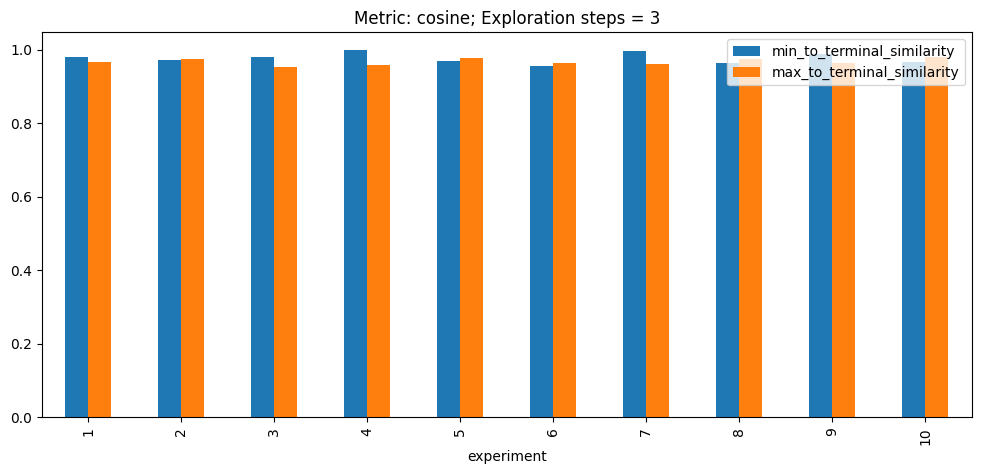

In [33]:
cosine_3k_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'cosine') & (visualization_df['k'] == 3)][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = cosine_3k_df.plot(
    kind='bar',
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: cosine; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

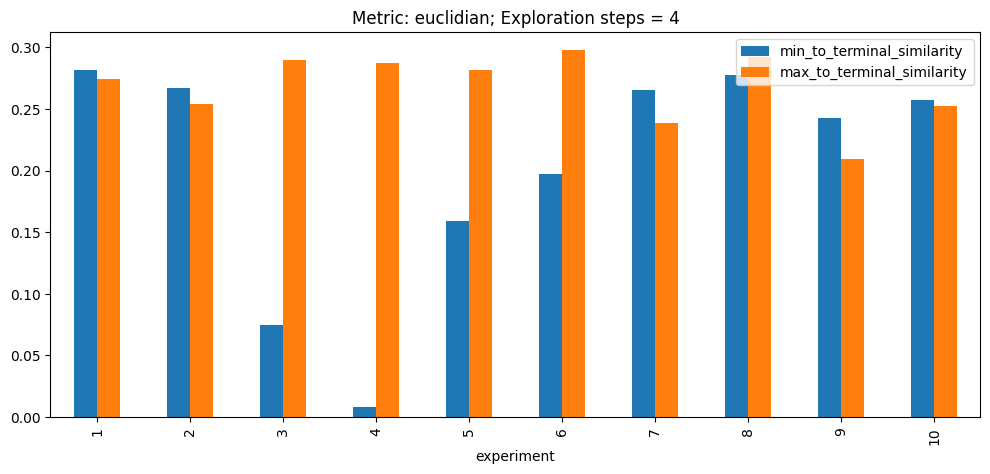

In [34]:
euclidian_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'euclidian') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = euclidian_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: euclidian; Exploration steps = 4',
    figsize=(12, 5)
)
plt.show()

In [35]:
euclidian_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'euclidian']

euclidian_experiments_success_condition = (euclidian_df['max_to_terminal_similarity'] < euclidian_df['min_to_terminal_similarity'])
euclidian_experiments_success_amount = len(euclidian_df.loc[euclidian_experiments_success_condition].values) / len(set(euclidian_df['k'].values))
euclidian_success_rate = euclidian_experiments_success_amount / len(set(euclidian_df['experiment'].values)) * 100

In [36]:
print(f"Success rate: {euclidian_success_rate}%")

Success rate: 36.666666666666664%


In [37]:
cosine_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'cosine']

cosine_experiments_success_condition = (cosine_df['max_to_terminal_similarity'] < cosine_df['min_to_terminal_similarity'])
cosine_experiments_success_amount = len(cosine_df.loc[cosine_experiments_success_condition].values) / len(set(cosine_df['k'].values))
cosine_success_rate = cosine_experiments_success_amount / len(set(cosine_df['experiment'].values)) * 100

In [38]:
print(f'Success rate: {cosine_success_rate}%')

Success rate: 60.0%


In [40]:
manhattan_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'manhattan']

manhattan_experiments_success_condition = (manhattan_df['max_to_terminal_similarity'] < manhattan_df['min_to_terminal_similarity'])
manhattan_experiments_success_amount = len(manhattan_df.loc[manhattan_experiments_success_condition].values) / len(set(manhattan_df['k'].values))
manhattan_success_rate = manhattan_experiments_success_amount / len(set(manhattan_df['experiment'].values)) * 100

In [41]:
print(f'Success rate: {manhattan_success_rate}%')

Success rate: 26.666666666666668%
